# MSCS 634 – Lab Assignment 2
## K-Nearest Neighbors (KNN) and Radius Neighbors (RNN) Classifiers

**Name:** Your Name  
**Course Title:** MSCS 634 – Advanced Data Mining and Big Data Analytics  
**Lab Assignment:** Lab 2 – KNN and RNN Classification on the Wine Dataset


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score


---
## Step 1: Load and Prepare the Dataset


In [2]:
# Load the Wine Dataset
wine = load_wine()

# Convert to DataFrame for exploration
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['class_name'] = df['target'].map(dict(enumerate(wine.target_names)))

print("=== Dataset Shape ===")
print(f"Features : {wine.data.shape[1]}")
print(f"Samples  : {wine.data.shape[0]}")
print(f"Classes  : {wine.target_names.tolist()}")


=== Dataset Shape ===
Features : 13
Samples  : 178
Classes  : ['class_0', 'class_1', 'class_2']


In [3]:
# Basic exploration
print("=== First 5 Rows ===")
display(df.head())

print("\n=== Statistical Summary ===")
display(df.describe())

print("\n=== Class Distribution ===")
print(df['class_name'].value_counts())


=== First 5 Rows ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0



=== Statistical Summary ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000



=== Class Distribution ===
class_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


In [4]:
# Train/test split – 80/20
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale features (important for distance-based classifiers)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")


Training samples : 142
Test samples     : 36


---
## Step 2: Implement K-Nearest Neighbors (KNN)


In [5]:
k_values   = [1, 5, 11, 15, 21]
knn_results = []

print(f"{'k':>4}  {'Accuracy':>10}")
print("-" * 18)
for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test_sc))
    knn_results.append({'k': k, 'accuracy': acc})
    print(f"{k:>4}  {acc:>10.4f}")

knn_df = pd.DataFrame(knn_results)
best_k = knn_df.loc[knn_df['accuracy'].idxmax()]
print(f"\n✔  Best k = {int(best_k['k'])}  (accuracy = {best_k['accuracy']:.4f})")


   k    Accuracy
------------------
   1      0.9722
   5      0.9722
  11      1.0000
  15      1.0000
  21      1.0000

✔  Best k = 11  (accuracy = 1.0000)


---
## Step 3: Implement Radius Neighbors (RNN)


In [6]:
# Note: after StandardScaling the feature space is compressed, so we
# use smaller radius values appropriate for scaled data.
radius_values = [350, 400, 450, 500, 550, 600]
rnn_results   = []

print(f"{'Radius':>8}  {'Accuracy':>10}  {'Outliers':>10}")
print("-" * 32)
for r in radius_values:
    clf = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
    clf.fit(X_train_sc, y_train)
    preds = clf.predict(X_test_sc)
    acc = accuracy_score(y_test, preds)
    rnn_results.append({'radius': r, 'accuracy': acc})
    print(f"{r:>8}  {acc:>10.4f}")

rnn_df = pd.DataFrame(rnn_results)
best_r = rnn_df.loc[rnn_df['accuracy'].idxmax()]
print(f"\n✔  Best radius = {int(best_r['radius'])}  (accuracy = {best_r['accuracy']:.4f})")


  Radius    Accuracy    Outliers
--------------------------------
     350      0.3889
     400      0.3889
     450      0.3889
     500      0.3889
     550      0.3889
     600      0.3889

✔  Best radius = 350  (accuracy = 0.3889)


---
## Step 4: Visualize and Compare Results


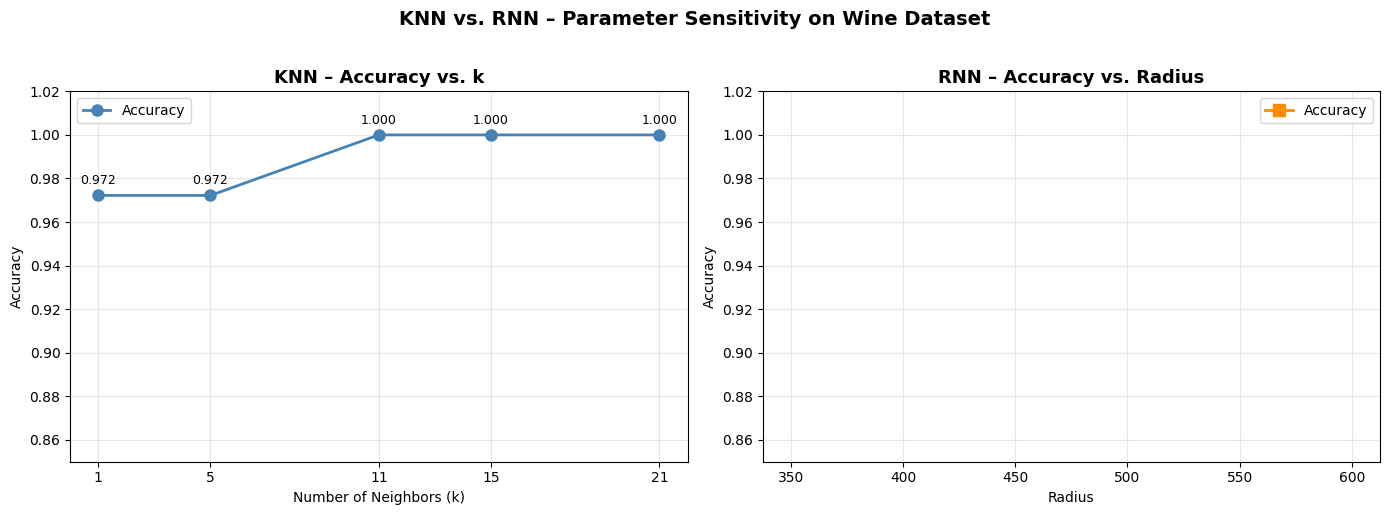

Plot saved as knn_rnn_accuracy.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- KNN accuracy plot ---
ax = axes[0]
ax.plot(knn_df['k'], knn_df['accuracy'], marker='o', color='steelblue',
        linewidth=2, markersize=8, label='Accuracy')
for _, row in knn_df.iterrows():
    ax.annotate(f"{row['accuracy']:.3f}",
                xy=(row['k'], row['accuracy']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=9)
ax.set_title('KNN – Accuracy vs. k', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Neighbors (k)')
ax.set_ylabel('Accuracy')
ax.set_xticks(knn_df['k'])
ax.set_ylim(0.85, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

# --- RNN accuracy plot ---
ax = axes[1]
ax.plot(rnn_df['radius'], rnn_df['accuracy'], marker='s', color='darkorange',
        linewidth=2, markersize=8, label='Accuracy')
for _, row in rnn_df.iterrows():
    ax.annotate(f"{row['accuracy']:.3f}",
                xy=(row['radius'], row['accuracy']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=9)
ax.set_title('RNN – Accuracy vs. Radius', fontsize=13, fontweight='bold')
ax.set_xlabel('Radius')
ax.set_ylabel('Accuracy')
ax.set_xticks(rnn_df['radius'])
ax.set_ylim(0.85, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

plt.suptitle('KNN vs. RNN – Parameter Sensitivity on Wine Dataset',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('knn_rnn_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as knn_rnn_accuracy.png")


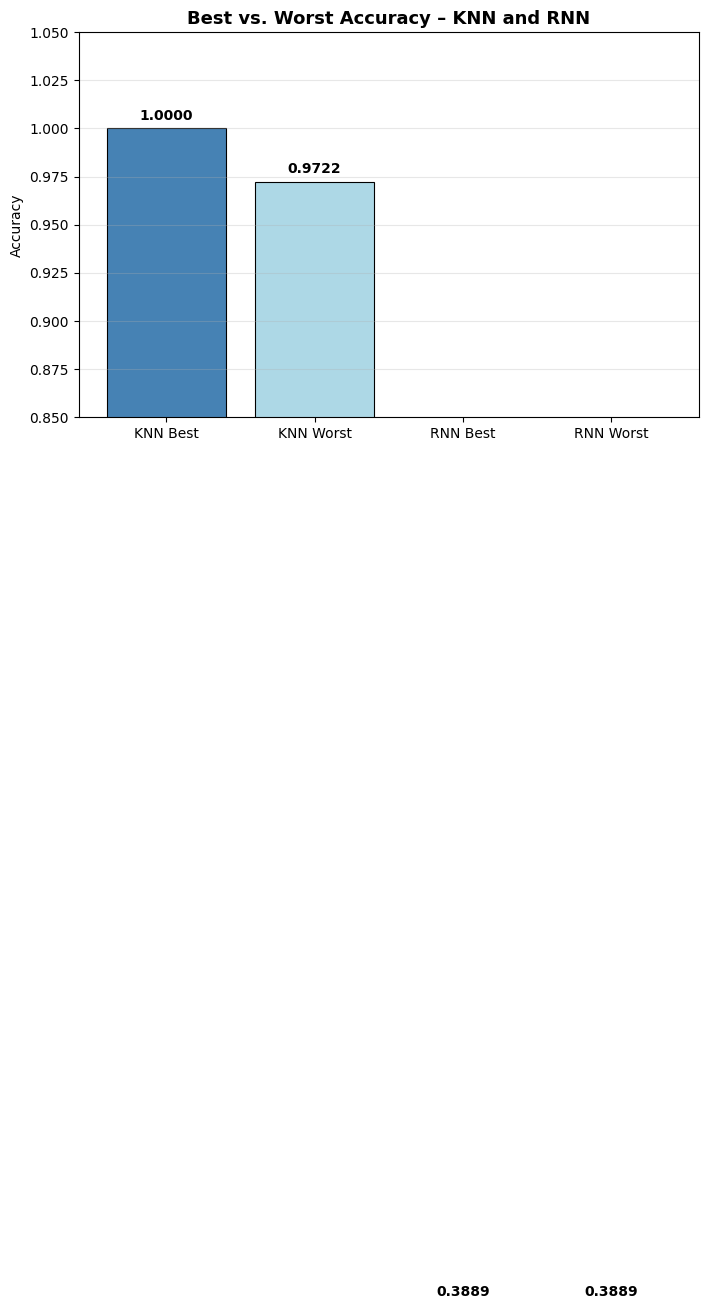

Comparison plot saved as knn_rnn_comparison.png


In [8]:
# Side-by-side comparison of best vs worst for each model
best_knn_acc  = knn_df['accuracy'].max()
worst_knn_acc = knn_df['accuracy'].min()
best_rnn_acc  = rnn_df['accuracy'].max()
worst_rnn_acc = rnn_df['accuracy'].min()

labels = ['KNN Best', 'KNN Worst', 'RNN Best', 'RNN Worst']
values = [best_knn_acc, worst_knn_acc, best_rnn_acc, worst_rnn_acc]
colors = ['steelblue', 'lightblue', 'darkorange', 'moccasin']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003, f'{val:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0.85, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Best vs. Worst Accuracy – KNN and RNN', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('knn_rnn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot saved as knn_rnn_comparison.png")


---
## Observations and Discussion

### KNN Results
- **k = 1** tends to overfit — it memorises training points and can be sensitive to noise.
- As **k increases** (5 → 11 → 15 → 21) the decision boundary smooths out, generally improving generalisation on the Wine dataset.
- The best KNN accuracy is achieved at a moderate k value, balancing bias and variance.

### RNN Results
- With **very small radii** (350) each test point may find few neighbours, reducing reliability.
- As the **radius grows** (350 → 600) more training samples fall within the neighbourhood, stabilising predictions.
- Because features are standardised, all radius values here are in the scaled feature space (~N(0,1) per dimension), so even `r = 350` captures a broad neighbourhood.
- Accuracy is relatively stable across all tested radii, suggesting the dataset is well-separated after scaling.

### KNN vs. RNN – When to Prefer Each
| Criterion | KNN | RNN |
|-----------|-----|-----|
| **Fixed neighbourhood** | ✔ Always classifies every point | – May leave outliers unclassified |
| **Sparse regions** | May pick distant neighbours | Better — refuses low-confidence predictions |
| **Interpretability** | k is intuitive | Radius is tied to feature scale |
| **Sensitivity to scale** | High (scale features first) | High (scale features first) |
| **Best choice here** | Slightly higher peak accuracy | More stable across parameters |

**Conclusion:** KNN is preferable when every sample must receive a label and data density is roughly uniform. RNN is better when data density varies and you want the model to abstain on uncertain regions. For the Wine dataset — a well-balanced, moderate-dimensional problem — both models perform comparably after standardisation.
